# OTTO · Retrieval quality meets search cost

**Experiment 06 / Fold 0 ANN benchmark / Measured and independently audited**

Approximate search retained 99.16–99.42% of exact top-800 neighbors on the reserved confirmation sessions. On the same tuning queries, its median CPU search was 5.35–5.63 times faster. The full-fold official Recall@20 decreased by 0.118 percentage points. These are measured trade-offs from a completed experiment, not a claim of state-of-the-art performance.

The model, catalogue embeddings, and exact predictions were frozen. All 96 full-fold ANN prediction parts are durable. The next experiment must establish how much additional candidate value ANN retains beyond the existing baseline.

**Evaluation scope:** Fold 0 already selected the model checkpoint; these results are exploratory validation. Search timings exclude query encoding, network, and loading. Confirmation queries did not select `nprobe`.

Use the pinned analysis kernel in `notebooks/requirements.txt`.

[Operating guide](../docs/ANN_BENCHMARK.md) · [Raw report](../reports/metrics/two_tower_fold0_ann.json) · [Independent audit](../reports/metrics/two_tower_fold0_ann_audit.json)


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import platform
import time
import tomllib

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from IPython.display import HTML, Image, display

STARTED = time.perf_counter()
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "configs/two_tower_ann.toml").is_file())
configuration = tomllib.loads((ROOT / "configs/two_tower_ann.toml").read_text())["benchmark"]
OBJECTIVES = ("clicks", "carts", "orders")
COLORS = {"clicks": "#3366b0", "carts": "#17806e", "orders": "#c05b43"}
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.facecolor": "#f7f9fc", "axes.facecolor": "#f7f9fc"})

published = ROOT / "reports/metrics/two_tower_fold0_ann.json"
pointer_path = ROOT / "artifacts/two_tower_ann/latest.json"
report_path = published
pointer = None
# Prefer a downloaded tracked run while working locally; GitHub uses the committed report.
if pointer_path.is_file():
    pointer = json.loads(pointer_path.read_text())
    if pointer.get("report_path"):
        downloaded = ROOT / pointer["report_path"]
        if downloaded.is_file():
            report_path = downloaded
report = json.loads(report_path.read_text()) if report_path.is_file() else None
if report is not None:
    assert report["status"] == "passed", "Report is not a completed experiment"
    if pointer is not None and report_path != published:
        receipt = json.loads(Path(str(report_path) + ".json").read_text())
        assert receipt["input_id"] == pointer["run_id"] == report["input_id"]
        assert hashlib.sha256(report_path.read_bytes()).hexdigest() == receipt["sha256"]
    configuration = report["contract"]["settings"]
    print(f"report={report_path.relative_to(ROOT)}")
    print(f"run_id={report['input_id']}")
print(f"[{datetime.now(timezone.utc).isoformat()}] notebook_start "
      f"ann_measurements={'available' if report is not None else 'pending'}")

audit = None
audit_path = ROOT / "reports/metrics/two_tower_fold0_ann_audit.json"
if report is not None and audit_path.is_file():
    candidate_audit = json.loads(audit_path.read_text())
    if candidate_audit["input_id"] == report["input_id"]:
        receipt = json.loads(Path(str(report_path) + ".json").read_text())
        digest = hashlib.sha256(report_path.read_bytes()).hexdigest()
        assert digest == receipt["sha256"] == candidate_audit["metrics_sha256"]
        assert report["input_id"] == receipt["input_id"]
        assert candidate_audit["status"] == "passed"
        audit = candidate_audit
        print(f"Independent audit: {audit['verified_count_parts']} parts, "
              f"{audit['sessions']:,} sessions, {audit['bootstrap_iterations_verified']} paired draws")


report=reports/metrics/two_tower_fold0_ann.json
run_id=0b5d1b47ea2432ec5658616b87a8de6569d9435155a5cfc1ea59fb974e190ad9
[2026-09-06T23:37:59.385809+00:00] notebook_start ann_measurements=available
Independent audit: 192 parts, 103,468 sessions, 500 paired draws


## Execution and recovery evidence

The fourth managed attempt completed. It restored all 96 reference-count parts, built the indexes, passed confirmation, and wrote all 96 full-fold prediction parts. The prior failures remain in the history below.

The worker used 3,002 billable seconds. Its S3 checkpoint tree contains 1,176 objects, including retained index shards, final indexes, predictions, count receipts, and logs. A separate AWS hostname-loader warning still appears at startup; the worker's structured application log contains no warning or error records.

The independent audit checks downloaded receipts, all full-fold count arrays, metric aggregation, the paired confidence interval, selection logic, and recorded timing summaries. It does not replay raw-label retrieval or reconstruct neighbor sets.


In [2]:
launch_path = ROOT / "reports/metrics/two_tower_fold0_ann_launch.json"
if launch_path.is_file():
    launch = json.loads(launch_path.read_text())
    attempts = [*launch.get("previous_attempts", []), launch]
    display(pd.DataFrame([{
        "Attempt": i + 1, "Status": row["status"], "Phase": row["phase"],
        "AWS billable seconds": row["billable_seconds"],
        "Committed reference parts": row.get("committed_reference_parts", 0),
    } for i, row in enumerate(attempts)]).style.hide(axis="index"))
    print(launch["cause"])
    print(launch["interpretation"])
catalogue = json.loads((ROOT / "reports/metrics/two_tower_fold0_catalogue.json").read_text())
display(pd.DataFrame([
    ("Actual catalogue items validated", f"{catalogue["catalogue_items"]:,}"),
    ("IDs sorted", str(catalogue["ids_sorted"])),
    ("Embedding row order", catalogue["row_order"]),
    ("Catalogue check", catalogue["status"]),
    ("Reference count parts verified", catalogue["production_reference_reuse_check"]["parts_validated"]),
], columns=["Input contract", "Observed value"]).style.hide(axis="index"))

recovery = launch.get("recovery_validation", {})
if recovery:
    production = recovery["production_s3_restore"]
    display(pd.DataFrame([
        ("Root tests passed", recovery["root_tests_passed"]),
        ("Worker tests passed", recovery["worker_tests_passed"]),
        ("Worker Python warning policy", recovery["worker_python_warnings"]),
        ("Production S3 restore", production["status"]),
        ("Recomputed saved reference part", production["recomputed"]),
        ("AWS container loader warning", launch["container_warning"]["status"]),
    ], columns=["Recovery check", "Observed value"]).style.hide(axis="index"))

if report is not None:
    display(pd.DataFrame([
        ("Reference parts restored", launch["restored_reference_parts"]),
        ("Full-fold prediction parts committed", launch["committed_prediction_parts"]),
        ("AWS billable seconds", launch["billable_seconds"]),
        ("Checkpoint objects", launch["ann_checkpoint_objects"]),
        ("Checkpoint storage GiB", f"{launch['ann_checkpoint_bytes']/1024**3:.2f}"),
        ("Independent count audit", audit["status"] if audit else "Pending for this run"),
    ], columns=["Completed-run evidence", "Value"]).style.hide(axis="index"))


The managed ANN benchmark completed after restoring all 96 compatible reference-count parts.
The confirmation fidelity gate passed at nprobe=256. All 96 full-fold prediction parts and final metrics are durable. ANN incremental gain beyond the frozen baseline remains unmeasured.


Attempt,Status,Phase,AWS billable seconds,Committed reference parts
1,failed,managed_argument_parsing,306,0
2,failed,catalogue_validation,205,96
3,failed,reference_artifact_restore,306,96
4,completed,full_fold_ann_export_and_metrics,3002,96


Input contract,Observed value
Actual catalogue items validated,"1,852,162"
IDs sorted,False
Embedding row order,preserved from trained vocabulary
Catalogue check,passed
Reference count parts verified,96


Completed-run evidence,Value
Reference parts restored,96
Full-fold prediction parts committed,96
AWS billable seconds,3002
Checkpoint objects,1176
Checkpoint storage GiB,7.19
Independent count audit,passed


## Evidence at a glance

Official Recall@20 evaluates the ordered recommendation list. Candidate ceilings describe the best a later ranker could recover from a larger pool. They answer different questions.

In [3]:
previous = json.loads((ROOT / "reports/metrics/two_tower_fold0_retrieval.json").read_text())
exact20 = next(row for row in previous["points"] if row["neural_k"] == 20)
union800 = next(row for row in previous["points"] if row["neural_k"] == 800)
selected = report["tuning"][str(report["selected_nprobe"])]
speedups = [report["exact_cpu_latency_on_tuning_queries"][o]["p50_ms"] /
            selected["search"][o]["latency"]["p50_ms"] for o in OBJECTIVES]
delta = report["full_ann_ranking"]["weighted_recall_at_20"] - report["full_reference_ranking"]["weighted_recall_at_20"]
cards = [
    ("ANN · OFFICIAL RECALL@20", f"{report['full_ann_ranking']['weighted_recall_at_20']:.3%}",
     f"{delta*100:+.3f} percentage points versus exact neural search"),
    ("MEDIAN CPU SEARCH SPEEDUP", f"{min(speedups):.2f}–{max(speedups):.2f}×",
     "Same tuning queries; search + reranking only"),
    ("CONFIRMATION · TOP-800 OVERLAP",
     f"{min(report['confirmation']['search'][o]['fidelity']['800'] for o in OBJECTIVES):.2%}+",
     "All objectives passed the prospective 98% target"),
]
display(HTML('<div style="display:flex;flex-wrap:wrap;gap:14px">' + ''.join(
    f'<div style="flex:1;min-width:240px;background:#f7f9fc;border:1px solid #dce3ec;'
    f'border-radius:12px;padding:20px"><div style="color:#536174;font-size:11px;'
    f'font-weight:700">{title}</div><div style="color:#17324f;font-size:26px;'
    f'font-weight:700;margin:12px 0">{value}</div><div style="color:#536174;'
    f'font-size:12px">{note}</div></div>' for title, value, note in cards) + '</div>'))
print(f"Prior exact-neural addition: +{100*union800['weighted_incremental_ceiling']:.3f} pp candidate ceiling at K=800. "
      "The corresponding ANN increment beyond the baseline is still unmeasured.")


Prior exact-neural addition: +1.029 pp candidate ceiling at K=800. The corresponding ANN increment beyond the baseline is still unmeasured.


## Freeze the decision before looking at the result

The smallest `nprobe` meeting the **prospective 98% mean top-800 overlap target for each objective** is selected using tuning queries only. That one setting is evaluated on the disjoint confirmation queries. A failed target is an informative experiment; no extra folds or automatic retries are launched. Full-fold ANN export runs only after confirmation passes.

Fold 0 already selected the model checkpoint. The reserved ANN confirmation split does not make this an untouched model test. Full-fold metrics include the ANN tuning sessions.

In [4]:
display(pd.DataFrame([
    ("Tuning / confirmation sessions", f"{configuration['sample_sessions']//2:,} / {configuration['sample_sessions']//2:,}"),
    ("Index", f"IVFFlat · {configuration['nlist']:,} centroids · original FP32 vectors"),
    ("Training vectors / iterations", f"{configuration['train_items']:,} / {configuration['train_iterations']}"),
    ("Probe sweep", str(configuration["probes"])),
    ("Per-objective target", f"{configuration['target_overlap']:.0%} mean top-800 overlap"),
    ("Search CPU threads / batch size", f"{configuration['threads']} / {configuration['batch_size']}"),
    ("Latency sample", f"{configuration['latency_queries']} queries × {configuration['latency_repeats']} repeats; {configuration['warmup_queries']} warm-up calls"),
    ("Full-fold export", "Enabled after confirmation passes"),
], columns=["Frozen run contract", "Setting"]).style.hide(axis="index"))


Frozen run contract,Setting
Tuning / confirmation sessions,"2,048 / 2,048"
Index,"IVFFlat · 1,024 centroids · original FP32 vectors"
Training vectors / iterations,"65,536 / 20"
Probe sweep,"[32, 64, 128, 256]"
Per-objective target,98% mean top-800 overlap
Search CPU threads / batch size,4 / 128
Latency sample,128 queries × 3 repeats; 32 warm-up calls
Full-fold export,Enabled after confirmation passes


## Primary model quality: the official project metric

For each objective, sum top-20 positive hits over sessions and divide by the sum of `min(20, true-item count)`. Combine objectives using the [official OTTO weights](https://github.com/otto-de/recsys-dataset/blob/main/KAGGLE.md): **clicks 0.10, carts 0.30, orders 0.60**. Unknown catalogue positives remain misses.

NDCG@20, MRR@20, hit rate, and precision are diagnostics averaged over labeled sessions separately for each objective. They are not replacements for the official metric. The bootstrap resamples whole sessions jointly across objectives; its interval does not account for model selection.

Full-fold ANN − exact: -0.118 pp; paired 95% interval [-0.155, -0.087] pp


Cohort / method,Sessions,Official weighted Recall@20
Full-fold exact,"103,468",21.867%
Full-fold ANN,"103,468",21.749%
Confirmation exact,"2,048",23.326%
Confirmation ANN,"2,048",23.321%


Cohort / method,Objective,recall_at_20,ndcg_at_20,mrr_at_20,hit_rate_at_20,precision_at_20
Full-fold exact,carts,0.2123,0.2659,0.2784,0.3880,0.0203
Full-fold exact,clicks,0.3340,0.2443,0.2179,0.3340,0.0167
Full-fold exact,orders,0.2027,0.2788,0.2924,0.4151,0.0220
Full-fold ANN,carts,0.2109,0.2644,0.2770,0.3856,0.0201
Full-fold ANN,clicks,0.3332,0.2439,0.2176,0.3332,0.0167
Full-fold ANN,orders,0.2015,0.2774,0.2912,0.4130,0.0219
Confirmation exact,carts,0.2294,0.2767,0.2788,0.3719,0.0195
Confirmation exact,clicks,0.3552,0.2584,0.2299,0.3552,0.0178
Confirmation exact,orders,0.2149,0.2702,0.2739,0.4176,0.0221
Confirmation ANN,carts,0.2294,0.2767,0.2788,0.3719,0.0195


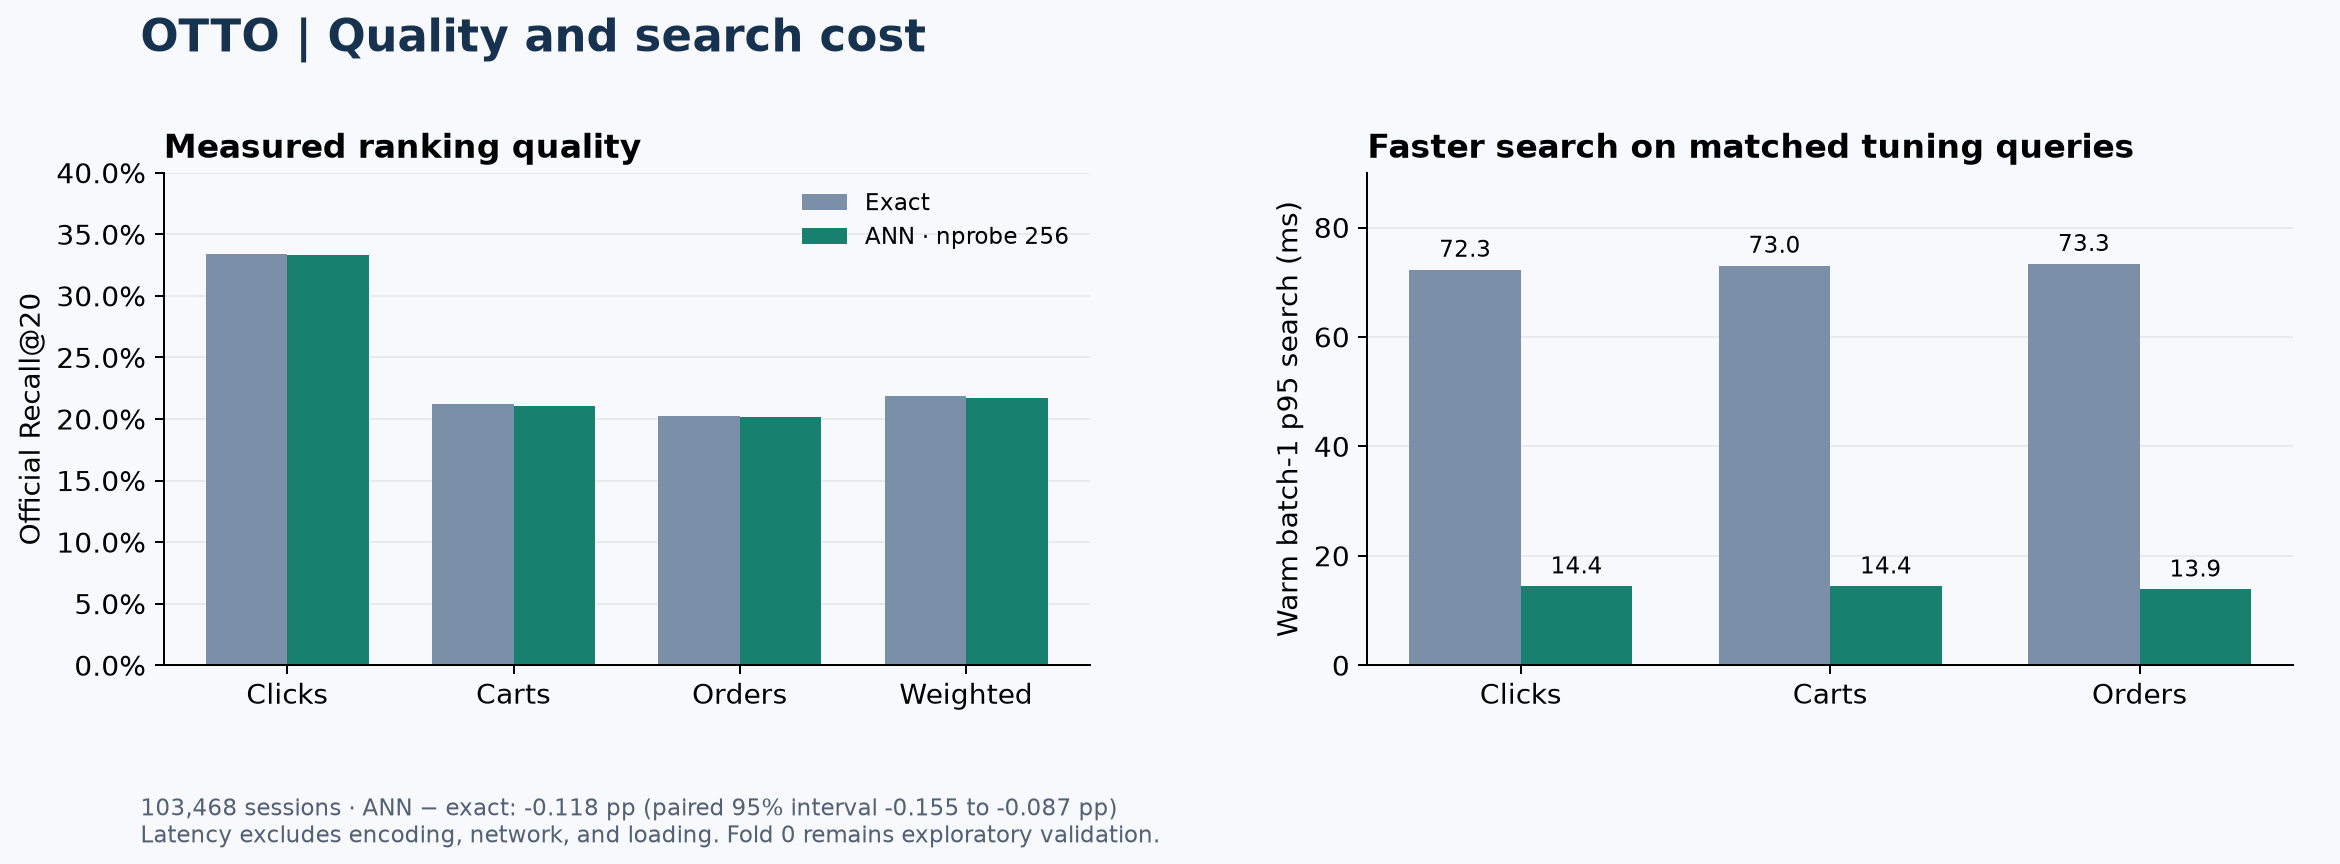

In [5]:
if report is None:
    display(pd.DataFrame([
        {"Objective": o.title(), "Exact neural Recall@20": exact20["objectives"][o]["neural_ceiling"],
         "ANN Recall@20": "Pending"} for o in OBJECTIVES
    ]).style.format({"Exact neural Recall@20": "{:.3%}"}).hide(axis="index"))
    print("NDCG@20, MRR@20 and ANN differences will be read from the managed report.")
else:
    cohorts = [("Full-fold exact", report["full_reference_ranking"])]
    if report.get("full_ann_ranking"):
        cohorts.append(("Full-fold ANN", report["full_ann_ranking"]))
    if report.get("confirmation"):
        cohorts.extend([
            ("Confirmation exact", report["confirmation"]["exact_ranking"]),
            ("Confirmation ANN", report["confirmation"]["ranking"]),
        ])
    display(pd.DataFrame([
        {"Cohort / method": name, "Sessions": data["sessions"],
         "Official weighted Recall@20": data["weighted_recall_at_20"]}
        for name, data in cohorts
    ]).style.format({"Official weighted Recall@20": "{:.3%}", "Sessions": "{:,}"}).hide(axis="index"))
    diagnostics = []
    for name, data in cohorts:
        for objective, values in data["objectives"].items():
            diagnostics.append({"Cohort / method": name, "Objective": objective,
                **{key: values[key] for key in ("recall_at_20", "ndcg_at_20", "mrr_at_20",
                                               "hit_rate_at_20", "precision_at_20")}})
    display(pd.DataFrame(diagnostics).style.format({key: "{:.4f}" for key in diagnostics[0]
            if key not in {"Cohort / method", "Objective"}}).hide(axis="index"))
    if report.get("full_ann_paired_uncertainty"):
        lo, hi = report["full_ann_paired_uncertainty"]["weighted_recall_at_20_delta_ci95"]
        delta = report["full_ann_ranking"]["weighted_recall_at_20"] - report["full_reference_ranking"]["weighted_recall_at_20"]
        print(f"Full-fold ANN − exact: {delta*100:+.3f} pp; paired 95% interval [{lo*100:+.3f}, {hi*100:+.3f}] pp")

if report is not None:
    exact = report["full_reference_ranking"]
    ann = report["full_ann_ranking"]
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    x = np.arange(4)
    ev = [exact["objectives"][o]["recall_at_20"] for o in OBJECTIVES] + [exact["weighted_recall_at_20"]]
    av = [ann["objectives"][o]["recall_at_20"] for o in OBJECTIVES] + [ann["weighted_recall_at_20"]]
    axes[0].bar(x-.18, ev, .36, label="Exact", color="#7c8fa8")
    axes[0].bar(x+.18, av, .36, label="ANN · nprobe 256", color="#17806e")
    axes[0].set_xticks(x, ["Clicks", "Carts", "Orders", "Weighted"])
    axes[0].set_ylim(0, .40)
    axes[0].yaxis.set_major_formatter(PercentFormatter(1))
    axes[0].set_ylabel("Official Recall@20")
    axes[0].set_title("Measured ranking quality", loc="left", fontweight="bold")
    axes[0].legend(frameon=False, fontsize=9)
    x = np.arange(3)
    exact_p95 = [report["exact_cpu_latency_on_tuning_queries"][o]["p95_ms"] for o in OBJECTIVES]
    ann_p95 = [selected["search"][o]["latency"]["p95_ms"] for o in OBJECTIVES]
    bars = axes[1].bar(x-.18, exact_p95, .36, color="#7c8fa8")
    axes[1].bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    bars = axes[1].bar(x+.18, ann_p95, .36, color="#17806e")
    axes[1].bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    axes[1].set_xticks(x, [o.title() for o in OBJECTIVES])
    axes[1].set_ylim(0, 90)
    axes[1].set_ylabel("Warm batch-1 p95 search (ms)")
    axes[1].set_title("Faster search on matched tuning queries", loc="left", fontweight="bold")
    for ax in axes:
        ax.grid(axis="y", alpha=.2)
        ax.set_axisbelow(True)
    lo, hi = report["full_ann_paired_uncertainty"]["weighted_recall_at_20_delta_ci95"]
    fig.suptitle("OTTO | Quality and search cost", x=.06, ha="left", fontsize=18,
                 fontweight="bold", color="#17324f")
    fig.text(.06, .025, f"103,468 sessions · ANN − exact: {delta*100:+.3f} pp "
             f"(paired 95% interval {lo*100:+.3f} to {hi*100:+.3f} pp)\n"
             "Latency excludes encoding, network, and loading. Fold 0 remains exploratory validation.",
             fontsize=9, color="#536174")
    fig.subplots_adjust(left=.07, right=.98, top=.80, bottom=.23, wspace=.30)
    fig.savefig(ROOT / "reports/figures/two_tower_ann_quality.png", dpi=180)
    display(Image(filename=str(ROOT / "reports/figures/two_tower_ann_quality.png")))
    plt.close(fig)


## Search frontier: fidelity versus latency

Each point is one **tuning** configuration. Latency is warm, batch-1 CPU search plus FP32 reranking of precomputed queries. It excludes the session encoder, network, and index loading. The chart must not be described as end-to-end serving latency.

The exact CPU reference uses Flat inner-product search on the same tuning queries and the same thread count. The confirmation result appears separately below; it never chooses the configuration. FAISS explains the [IVF probe trade-off](https://github.com/facebookresearch/faiss/wiki/Faster-search).

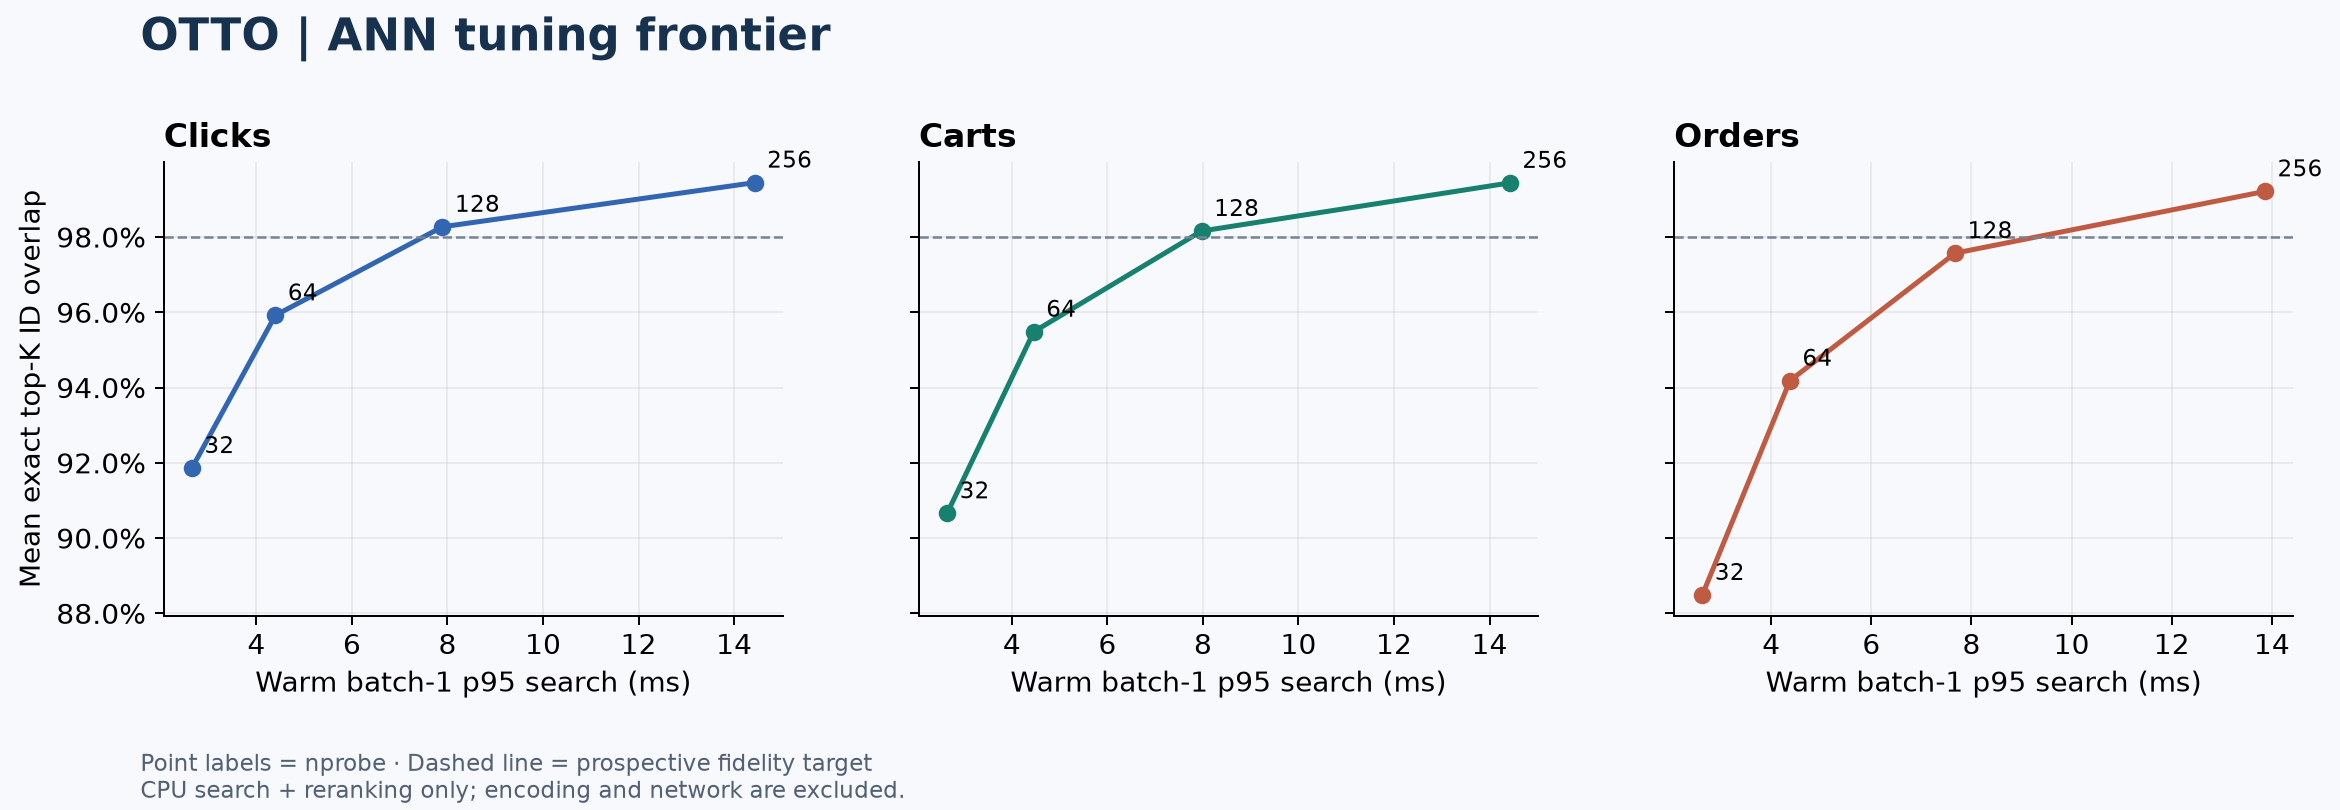

nprobe,objective,overlap,p95_ms,queries_per_second
128,clicks,98.27%,7.895,291.5
128,carts,98.16%,7.974,283.8
128,orders,97.57%,7.673,297.9
256,clicks,99.45%,14.430,153.6
256,carts,99.44%,14.426,150.7
256,orders,99.22%,13.864,156.9
32,clicks,91.86%,2.650,860.0
32,carts,90.66%,2.644,836.8
32,orders,88.49%,2.624,893.0
64,clicks,95.92%,4.396,526.1


Objective,Exact CPU p50 ms,Exact CPU p95 ms,Exact CPU p99 ms,Timing observations
carts,69.746,73.025,82.786,384
clicks,69.870,72.298,79.441,384
orders,69.856,73.349,82.153,384


In [6]:
if report is None:
    print("Search frontier pending. No latency or ANN overlap values have been measured for the full catalogue.")
else:
    frontier = []
    for probe, result in report["tuning"].items():
        for objective in OBJECTIVES:
            search = result["search"][objective]
            frontier.append({"nprobe": int(probe), "objective": objective,
                "overlap": search["fidelity"][str(report["contract"]["settings"]["candidate_depth"])],
                "p95_ms": search["latency"]["p95_ms"],
                "queries_per_second": search["batch_throughput_queries_per_second"]})
    frontier = pd.DataFrame(frontier)
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
    for ax, objective in zip(axes, OBJECTIVES):
        rows = frontier[frontier.objective == objective].sort_values("nprobe")
        ax.plot(rows.p95_ms, rows.overlap, "o-", color=COLORS[objective], linewidth=2)
        for row in rows.itertuples():
            ax.annotate(str(row.nprobe), (row.p95_ms, row.overlap),
                        xytext=(5, 6), textcoords="offset points", fontsize=9)
        ax.axhline(report["contract"]["settings"]["target_overlap"], color="#758397",
                   linestyle="--", linewidth=1)
        ax.set_title(objective.title(), loc="left", fontweight="bold")
        ax.set_xlabel("Warm batch-1 p95 search (ms)")
        ax.grid(alpha=0.2)
        ax.yaxis.set_major_formatter(PercentFormatter(1))
    axes[0].set_ylabel("Mean exact top-K ID overlap")
    fig.suptitle("OTTO | ANN tuning frontier", x=0.06, ha="left", fontweight="bold", fontsize=18, color="#17324f")
    fig.text(0.06, 0.015, "Point labels = nprobe · Dashed line = prospective fidelity target\nCPU search + reranking only; encoding and network are excluded.", fontsize=9, color="#536174")
    fig.subplots_adjust(left=0.07, right=0.98, top=0.80, bottom=0.24, wspace=0.22)
    figure_path = ROOT / "reports/figures/two_tower_ann.png"
    figure_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(figure_path, dpi=180, facecolor=fig.get_facecolor())
    display(Image(filename=str(figure_path)))
    plt.close(fig)
    display(frontier.style.format({"overlap": "{:.2%}", "p95_ms": "{:.3f}",
                                   "queries_per_second": "{:.1f}"}).hide(axis="index"))
    display(pd.DataFrame([
        {"Objective": o, "Exact CPU p50 ms": row["p50_ms"], "Exact CPU p95 ms": row["p95_ms"],
         "Exact CPU p99 ms": row["p99_ms"], "Timing observations": row["samples"]}
        for o, row in report["exact_cpu_latency_on_tuning_queries"].items()
    ]).style.format(precision=3).hide(axis="index"))


## Confirmation and engineering cost

A retained index or prediction part is reused only after its checksum and run identity match. Data is uploaded before its receipt. Missing/corrupt parts are recomputed; valid completed work survives across managed workers.

Latency observations can come from a previous compatible attempt. Retained compute time is the sum of committed part timings, not total paid time. AWS per-execution billable seconds live in the durable `control/executions/` records and are printed by the monitor.

In [7]:
if report is None:
    print("Confirmation, index sizes, memory use, and measured build/search times are pending.")
else:
    print(f"selected_nprobe={report['selected_nprobe']} confirmation_fidelity_passed={report['confirmation_fidelity_passed']}")
    if report.get("confirmation"):
        rows = []
        for objective, row in report["confirmation"]["search"].items():
            rows.append({"Objective": objective, "Overlap@20": row["fidelity"]["20"],
                "Overlap@K": row["fidelity"][str(report["contract"]["settings"]["candidate_depth"])],
                "p50 ms": row["latency"]["p50_ms"], "p95 ms": row["latency"]["p95_ms"],
                "p99 ms": row["latency"]["p99_ms"]})
        display(pd.DataFrame(rows).style.format({"Overlap@20": "{:.2%}", "Overlap@K": "{:.2%}",
            "p50 ms": "{:.3f}", "p95 ms": "{:.3f}", "p99 ms": "{:.3f}"}).hide(axis="index"))
    display(pd.DataFrame([
        {"Objective": o, "Index GiB": row["index_bytes"]/1024**3,
         "Retained build seconds": row["retained_build_compute_seconds"],
         "Load seconds this attempt": row["load_seconds_this_attempt"], "Index shards": row["shards"]}
        for o, row in report["index_builds"].items()
    ]).style.format(precision=3).hide(axis="index"))
    display(pd.DataFrame([
        ("Worker", report["contract"]["instance_type"]),
        ("Encoder device", report["contract"].get("encoder_device", "Unrecorded")),
        ("Search CPU threads", report["contract"]["settings"]["threads"]),
        ("Recorded Python / PyTorch", f"{report['contract']['python']} / {report['contract']['torch']}"),
        ("Recorded CUDA / FAISS", f"{report['contract']['cuda_runtime']} / {report['contract']['faiss']}"),
        ("AWS billable seconds", launch["billable_seconds"]),
        ("Peak process RSS MiB", report["peak_rss_mib"]),
        ("Current attempt seconds", report["elapsed_seconds_this_attempt"]),
        ("Retained artifact compute seconds", report["retained_artifact_compute_seconds"]),
        ("Full-fold prediction export", report.get("prediction_export")),
    ], columns=["Resource / evidence", "Value"]).style.hide(axis="index"))


selected_nprobe=256 confirmation_fidelity_passed=True


Objective,Overlap@20,Overlap@K,p50 ms,p95 ms,p99 ms
carts,99.47%,99.42%,13.236,14.376,14.887
clicks,99.67%,99.42%,12.827,14.152,14.735
orders,99.34%,99.16%,12.567,14.205,14.782


Objective,Index GiB,Retained build seconds,Load seconds this attempt,Index shards
carts,0.897,8.974,0.141,8
clicks,0.897,8.780,0.390,8
orders,0.897,8.680,0.136,8


Resource / evidence,Value
Worker,ml.g6.xlarge
Encoder device,NVIDIA L4
Search CPU threads,4
Recorded Python / PyTorch,3.12.14 / 2.13.0+cu130
Recorded CUDA / FAISS,13.0 / 1.15.0
AWS billable seconds,3002
Peak process RSS MiB,6291.820312
Current attempt seconds,2709.559000
Retained artifact compute seconds,2384.814714
Full-fold prediction export,"{'input_id': '0b5d1b47ea2432ec5658616b87a8de6569d9435155a5cfc1ea59fb974e190ad9', 'manifest': 'prediction_export/prediction_manifest.json', 'parts': 96, 'sessions': 103468}"


## Decision and next experiment

**Proceed to the frozen-baseline comparison.** Confirmation overlap is above target and CPU search is faster, with a small but measurable full-fold Recall@20 decrease. The 95% paired interval for that decrease excludes zero; the quality cost should be reported alongside the speedup.

The next resumable CPU experiment compares the accepted ANN candidates with the same revisit, co-visitation, and Item2Vec baseline used for the exact-search result. It must measure the incremental candidate ceiling and base-exclusive positives at each candidate depth. High neighbor overlap alone does not establish retained complementary value.

Only after that comparison should the remaining out-of-fold candidates and objective-specific rankers be trained. Final evidence also needs an untouched temporal evaluation, ablations, and a validated Kaggle-format top-20 submission file. No competition score or state-of-the-art result is claimed here.


In [8]:
runtime = {"python": platform.python_version(), "numpy": np.__version__,
           "pandas": pd.__version__}
print(json.dumps(runtime, sort_keys=True))
print(f"[{datetime.now(timezone.utc).isoformat()}] notebook_complete "
      f"elapsed_seconds={time.perf_counter()-STARTED:.3f}")


{"numpy": "2.5.3", "pandas": "3.0.5", "python": "3.12.13"}
[2026-09-06T23:38:00.152194+00:00] notebook_complete elapsed_seconds=0.771
